1.MEASURING THE IMPACT OF CT SKILLS ON SUCCESS

In [1]:
import pandas as pd

file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)
df.loc[75, 'A2.1-1.6'] = None

core_columns = ['M1-1', 'PA1-1', 'D1-1', 'A2.1-1.6', 'Nota Examen']
correlation = df[core_columns].corr()['Nota Examen'].drop('Nota Examen')

# --- STEP 4: PERCENTAGE IMPACT OF CT SKILLS ON THE FINAL SCORE (R-SQUARED) ---
print("--- CT SKILLS' DETERMINATION PERCENTAGES ON FINAL SCORE (%) ---")
impact_percentage = (correlation ** 2) * 100
print(impact_percentage.sort_values(ascending=False).round(1))

--- CT SKILLS' DETERMINATION PERCENTAGES ON FINAL SCORE (%) ---
A2.1-1.6    43.7
M1-1        20.3
D1-1        19.5
PA1-1       17.5
Name: Nota Examen, dtype: float64


2.OVERVIEW OF THE STUDENT COHORT

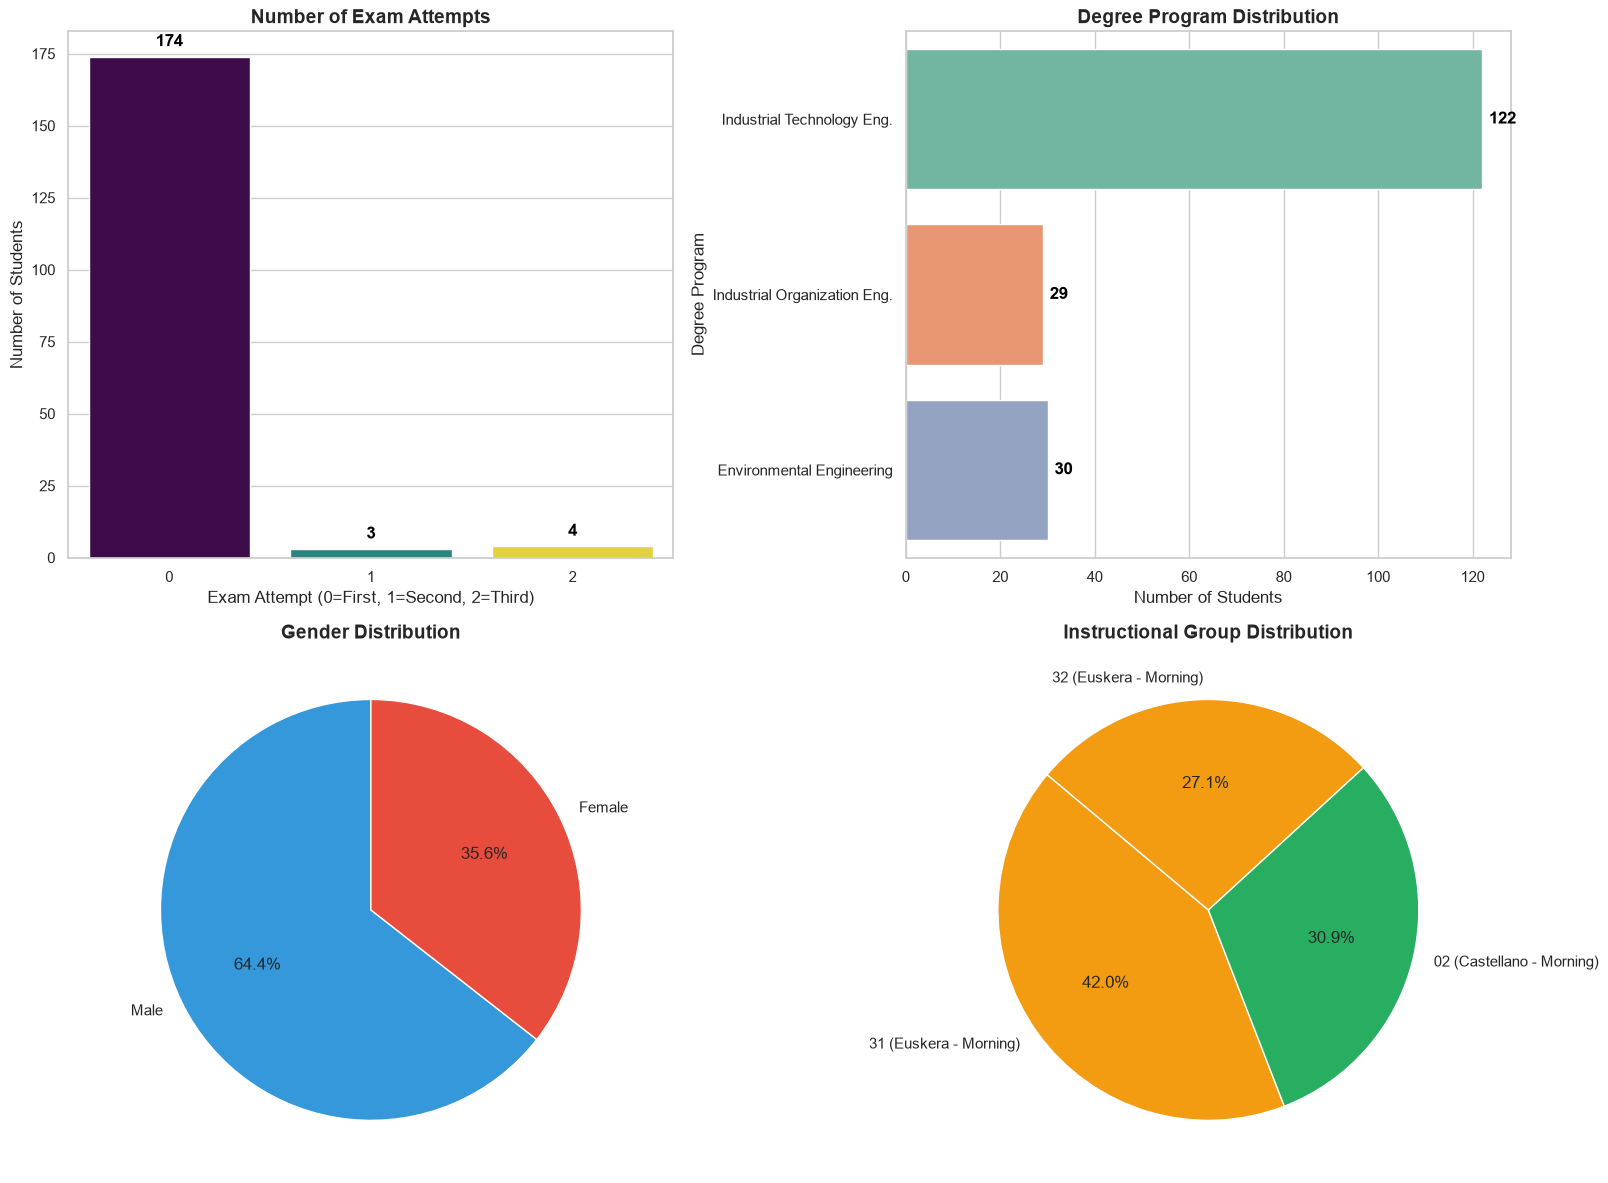

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA LOADING ---
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# --- ENGLISH DATA TRANSLATION (Replacing labels in the dataset) ---
# Translate Degree Program (Titulación) names to English
df['TITULACIÓN'] = df['TITULACIÓN'].replace({
    'Grado en Ingeniería en Tecnología Industrial': 'Industrial Technology Eng.',
    'Grado en Ingeniería en Organización Industrial': 'Industrial Organization Eng.',
    'Grado en Ingeniería Ambiental': 'Environmental Engineering'
})

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 12))

# Graph 1: Number of Exam Attempts (Top Left)
plt.subplot(2, 2, 1)
if 'CONVOCATORIAS' in df.columns:
    ax1 = sns.countplot(data=df, x='CONVOCATORIAS', hue='CONVOCATORIAS', palette='viridis', legend=False)
    plt.title("Number of Exam Attempts", fontweight='bold', fontsize=14)
    plt.ylabel("Number of Students")
    plt.xlabel("Exam Attempt (0=First, 1=Second, 2=Third)")
    
    # LOOP TO PRINT NUMBERS (LABELS) ON THE BARS
    for p in ax1.patches:
        ax1.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

# Graph 2: Degree Program Distribution (Top Right)
degree_column = 'TITULACIÓN' 
plt.subplot(2, 2, 2)
if degree_column in df.columns:
    ax2 = sns.countplot(data=df, y=degree_column, hue=degree_column, palette='Set2', legend=False)
    plt.title("Degree Program Distribution", fontweight='bold', fontsize=14)
    plt.xlabel("Number of Students")
    plt.ylabel("Degree Program")
    
    # PRINTING NUMBERS NEXT TO THE DEGREE BARS
    for p in ax2.patches:
        ax2.annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=12, fontweight='bold', color='black', xytext=(5, 0), textcoords='offset points')

# Graph 3: Gender Distribution (Bottom Left) - SMART SEARCH
plt.subplot(2, 2, 3)
gender_col_candidates = [col for col in df.columns if 'CHICO' in str(col).upper()]

if gender_col_candidates:
    actual_gender_col = gender_col_candidates[0]
    # Mapping gender labels to English
    df['Gender_Label'] = df[actual_gender_col].map({0.0: 'Male', 1.0: 'Female'})
    gender_counts = df['Gender_Label'].value_counts()
    plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#3498db', '#e74c3c'])
    plt.title("Gender Distribution", fontweight='bold', fontsize=14)

# Graph 4: Castellano / Euskera Group Distribution (Bottom Right)
group_col = 'GRUPO' 
plt.subplot(2, 2, 4)
if group_col in df.columns:
    group_counts = df[group_col].value_counts()
    
    # List comprehension to replace "Mañana" with "Morning"
    english_group_labels = [str(label).replace('Mañana', 'Morning') for label in group_counts.index]
    
    plt.pie(group_counts, labels=english_group_labels, autopct='%1.1f%%', startangle=140, colors=['#f39c12', '#27ae60'])
    plt.title("Instructional Group Distribution", fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

3.CORRELATION MATRIX OF COMPUTATIONAL THINKING SKILLS AND FINAL EXAM SCORE

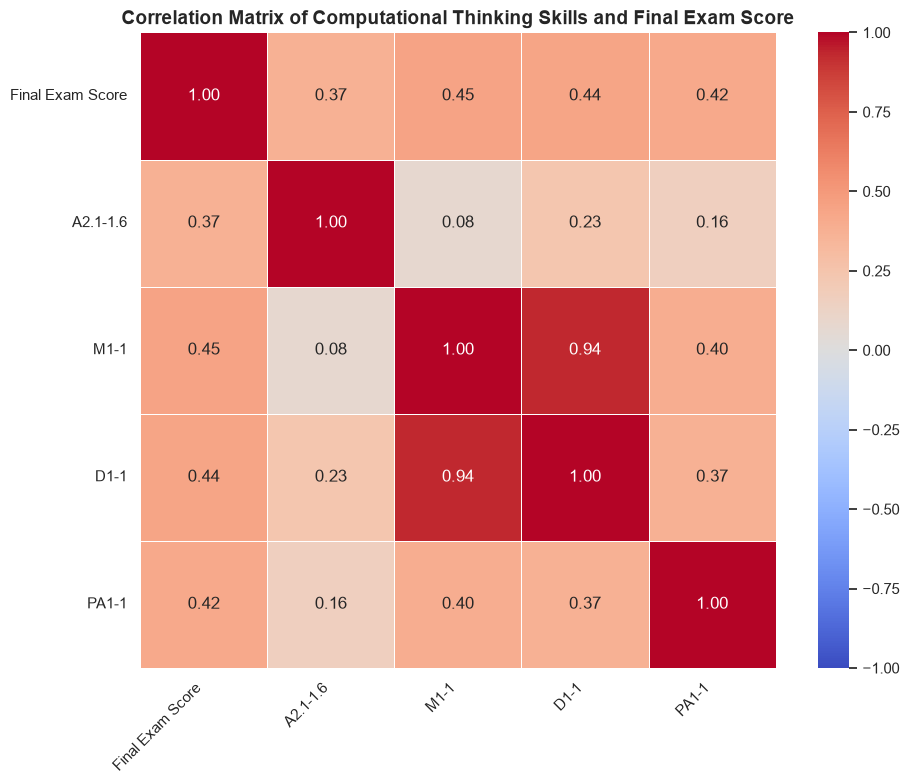

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA LOADING ---
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# --- ENGLISH DATA TRANSLATION ---
# Renaming "Nota Examen" to English for correct axis display
df = df.rename(columns={'Nota Examen': 'Final Exam Score'})

# Selecting only the NUMERICAL columns we want to analyze
relevant_columns = ['Final Exam Score', 'A2.1-1.6', 'M1-1', 'D1-1', 'PA1-1']

# Checking if these columns actually exist to avoid errors
existing_columns = [col for col in relevant_columns if col in df.columns]
df_numeric = df[existing_columns]

# Calculating the correlation matrix (using Pearson method)
correlation_matrix = df_numeric.corr()

# --- PLOTTING THE HEATMAP ---
plt.figure(figsize=(10, 8))

# printing numbers with annot=True, setting color theme with cmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5, square=True)

# Fully formatted the title to academic English
plt.title("Correlation Matrix of Computational Thinking Skills and Final Exam Score", fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

4.REGRESSION ANALYSIS

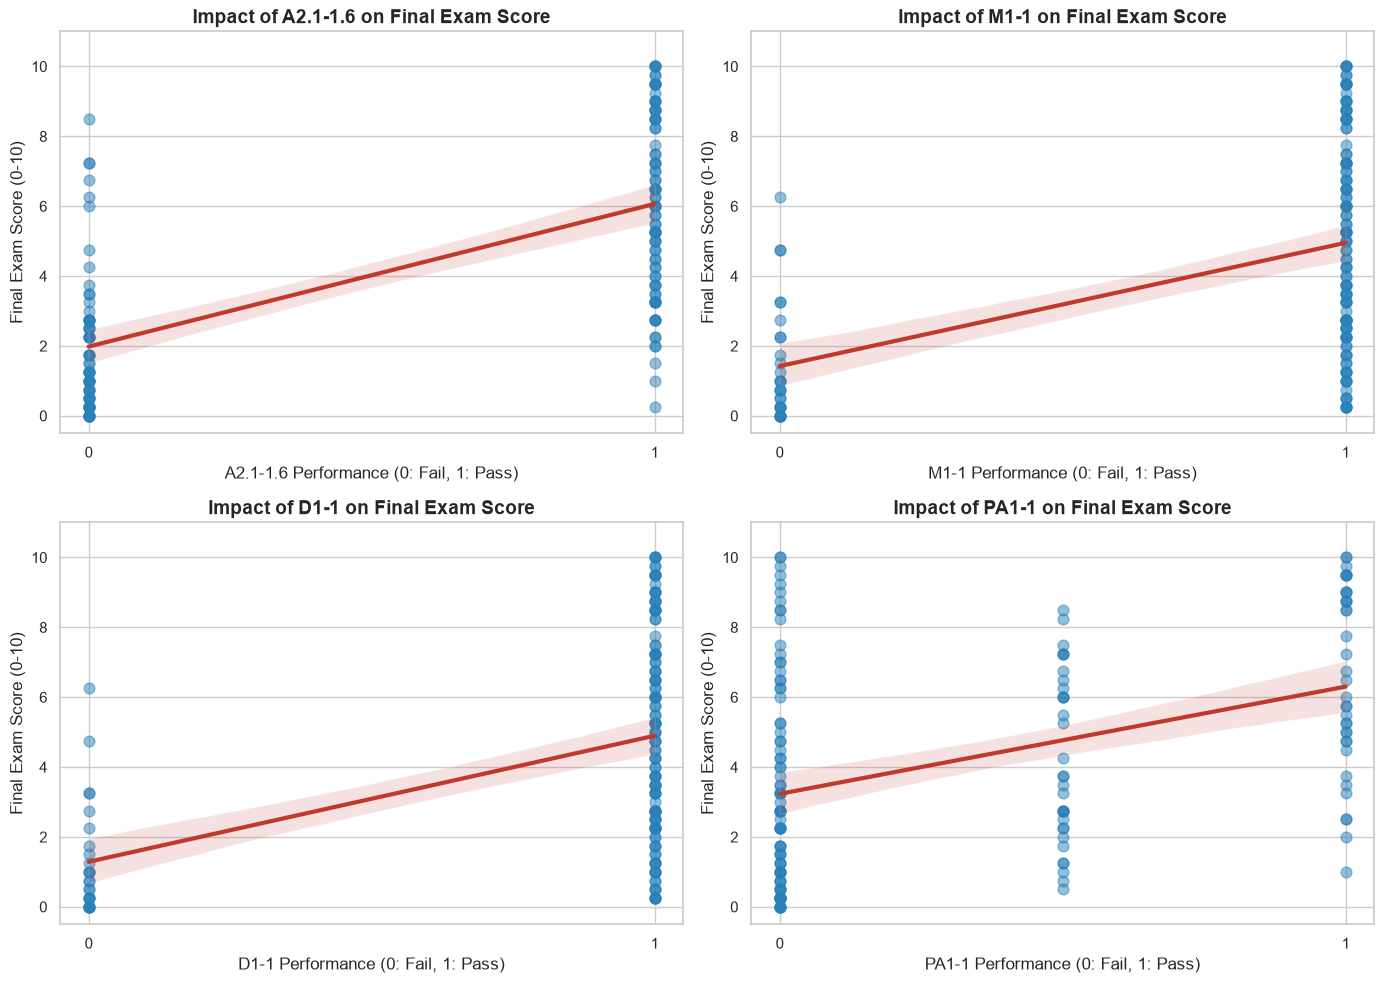

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA LOADING AND CLEANING ---
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)
# Removing erroneous data before analysis
df.loc[75, 'A2.1-1.6'] = None 

# --- VISUALIZATION ---
# The 4 main skills we will focus on
skills = ['A2.1-1.6', 'M1-1', 'D1-1', 'PA1-1']

# Setting the background style of the graph
sns.set_theme(style="whitegrid")

# Opening a canvas to fit 4 graphs
plt.figure(figsize=(14, 10))

# Iterating through skills to create a 4-part (2x2) grid
for i, skill in enumerate(skills, 1):
    plt.subplot(2, 2, i) 
    
    # Plotting scatter plot and red Regression line
    sns.regplot(data=df, x=skill, y='Nota Examen', 
                scatter_kws={'alpha': 0.5, 'color': '#2980b9', 's': 60}, 
                line_kws={'color': '#c0392b', 'linewidth': 3})
    
    # Titles and Axis Labels (COMPLETELY ENGLISH)
    plt.title(f"Impact of {skill} on Final Exam Score", fontsize=14, fontweight='bold')
    plt.xlabel(f"{skill} Performance (0: Fail, 1: Pass)", fontsize=12)
    plt.ylabel("Final Exam Score (0-10)", fontsize=12)
    
    # Fixing axes for proper display
    plt.xticks([0, 1]) 
    plt.ylim(-0.5, 11) 

# Spreading graphs proportionally on the canvas
plt.tight_layout()

# Displaying the plot
plt.show()

5.TOP 5 DRIVERS OF THE FINAL EXAM SCORE


=== Closest Associates of the A2.1-1.6 Skill (Highest Correlation) ===
A2.1-1.5    0.531240
M2.1-3      0.510944
A2.1-2.1    0.484276
R2.1-1      0.482919
A2.1-1.3    0.473303
Name: A2.1-1.6, dtype: float64

=== Top 5 Skills Affecting the FINAL SCORE (Nota Examen) ===
Nota Ejercicio 5    0.897378
Nota Ejercicio 4    0.760118
PA2.1-4             0.754653
PA1-5               0.734245
R2.1-1              0.722893
Name: Nota Examen, dtype: float64


/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_24736/3857744419.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_corr.values, y=top_5_corr.index, palette='viridis')


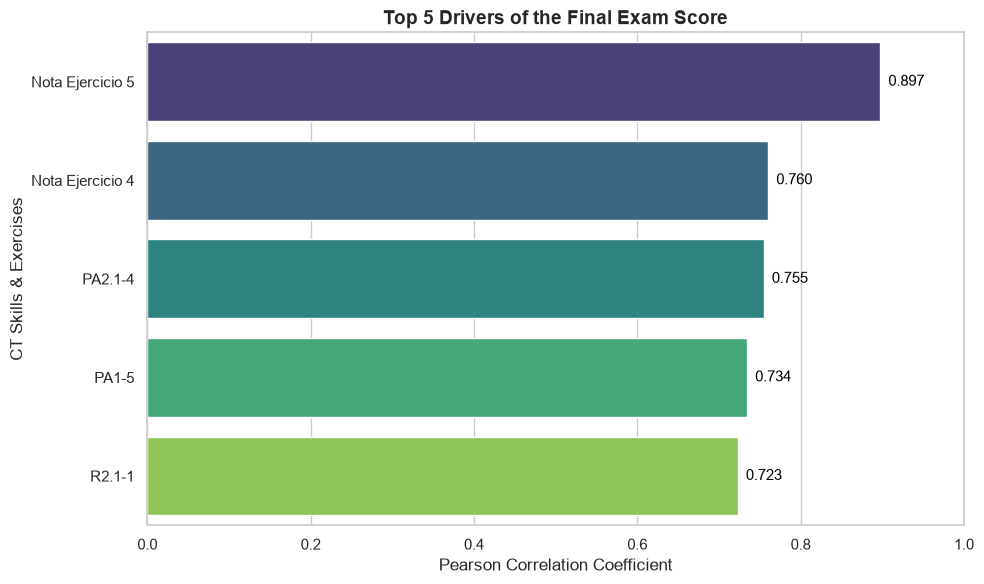

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data and extracting numerical values
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# Selecting only numerical data
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calculating the correlation matrix
correlation_matrix = df_numeric.corr()

print("\n=== Closest Associates of the A2.1-1.6 Skill (Highest Correlation) ===")
if 'A2.1-1.6' in correlation_matrix.columns:
    print(correlation_matrix['A2.1-1.6'].sort_values(ascending=False).iloc[1:6])

print("\n=== Top 5 Skills Affecting the FINAL SCORE (Nota Examen) ===")
if 'Nota Examen' in correlation_matrix.columns:
    print(correlation_matrix['Nota Examen'].sort_values(ascending=False).iloc[1:6])

# Extracting the top 5 skills affecting the final score
top_5_corr = correlation_matrix['Nota Examen'].sort_values(ascending=False).iloc[1:6]

# --- PLOTTING STAGE ---
plt.figure(figsize=(10, 6))

# Horizontal bar chart with Seaborn 
sns.barplot(x=top_5_corr.values, y=top_5_corr.index, palette='viridis')

# Adding title and axis labels to the graph
plt.title('Top 5 Drivers of the Final Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('CT Skills & Exercises', fontsize=12)

# Fixing X-axis between 0 and 1 since correlation values fall within this range
plt.xlim(0, 1.0)

# Printing exact numbers next to bars (for readability)
for index, value in enumerate(top_5_corr.values):
    plt.text(value + 0.01, index, f'{value:.3f}', va='center', fontsize=11, color='black')

plt.tight_layout()
plt.show()

6.TEACHER PERCEPTION VERSUS DATA REALITY

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_24736/1164148453.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=plot_data.values, y=plot_data.index, palette=color_palette)


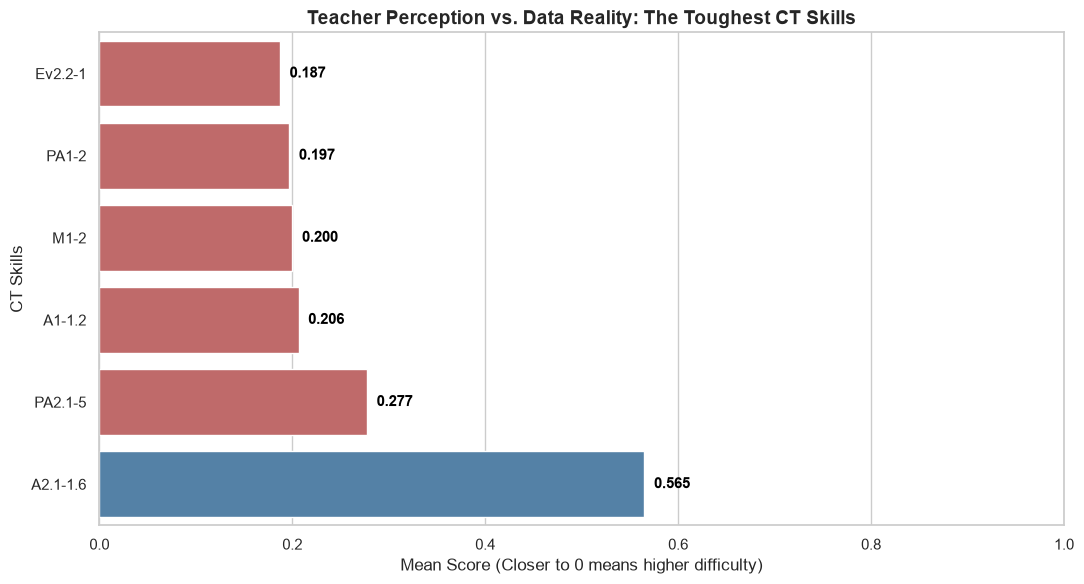

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading and Correcting Data
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

df['A2.1-1.6'] = pd.to_numeric(df['A2.1-1.6'], errors='coerce')
df.loc[df['A2.1-1.6'] == 10.0, 'A2.1-1.6'] = np.nan # Deleting the erroneous value 10

# 2. Selecting Only Numerical Data
df_numeric = df.select_dtypes(include=['float64', 'int64'])
skill_means = df_numeric.mean()

# 3. Data Cleaning (Removing non-skill Metadata columns)
unwanted_columns = ['Aj1', 'J1', 'CONVOCATORIAS', 'CHICO = 0    CHICA = 1']
skill_means = skill_means.drop(labels=[col for col in unwanted_columns if col in skill_means.index])

# 4. The Truly Toughest 5 Skills (Lowest Means)
toughest_5 = skill_means.sort_values(ascending=True).head(5)

# 5. A2.1-1.6 data
a2_1_6_mean = skill_means['A2.1-1.6']

# 6. Merging data for the graph
plot_data = pd.concat([toughest_5, pd.Series({'A2.1-1.6': a2_1_6_mean})])

# 7. VISUALIZATION
plt.figure(figsize=(11, 6))

# Using Red for the toughest 5 skills, Blue for A2.1-1.6
color_palette = ['indianred'] * 5 + ['steelblue']

ax = sns.barplot(x=plot_data.values, y=plot_data.index, palette=color_palette)

plt.title('Teacher Perception vs. Data Reality: The Toughest CT Skills', fontsize=14, fontweight='bold')
plt.xlabel('Mean Score (Closer to 0 means higher difficulty)', fontsize=12)
plt.ylabel('CT Skills', fontsize=12)
plt.xlim(0, 1.0)

# Printing exact values next to the bars
for index, value in enumerate(plot_data.values):
    ax.text(value + 0.01, index, f"{value:.3f}", color='black', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

7.FINAL EXAM AND ALGORITHMIC THINKING PERFORMANCE BY LANGUAGE OF INSTRUCTION

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_24736/2635536001.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Language', y='Nota Examen', ax=axes[0], palette="Set2")
/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_24736/2635536001.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Language', y='PA1-1', ax=axes[1], palette="Set3")


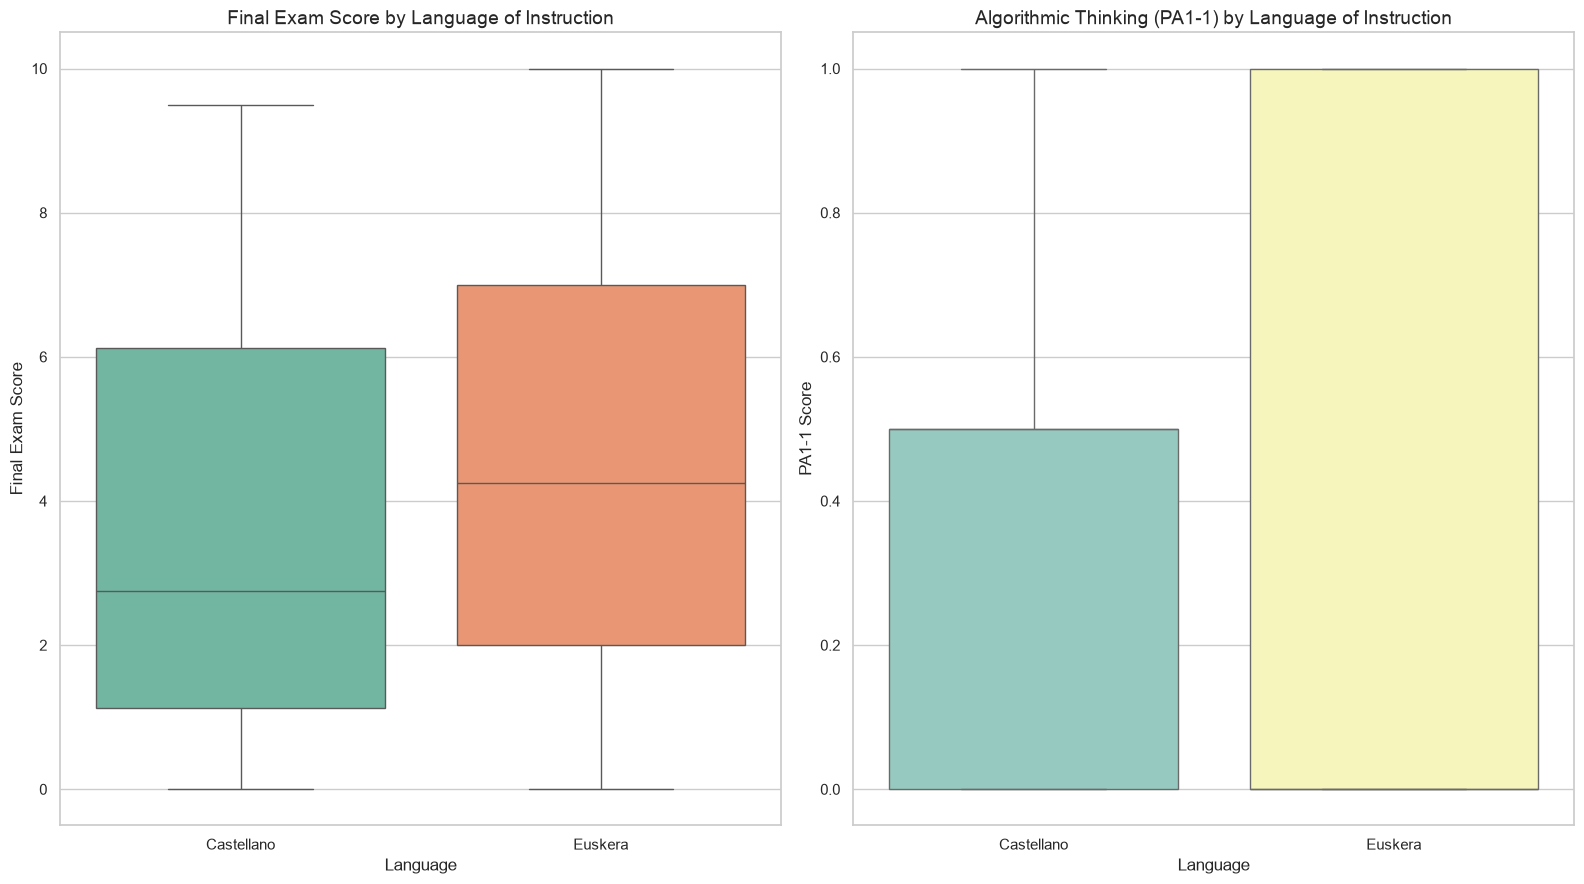

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA LOADING ---
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# --- 2. DATA PREPARATION (Language Distinction) ---
# Determining the language of instruction by examining the GRUPO column:
def determine_language(group):
    group_str = str(group)
    if '02' in group_str:
        return 'Castellano'
    elif '31' in group_str or '32' in group_str:
        return 'Euskera'
    return None

# Creating a new column named 'Language'
df['Language'] = df['GRUPO'].apply(determine_language)

# --- 3. VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Left Graph: Final Exam Score
sns.boxplot(data=df, x='Language', y='Nota Examen', ax=axes[0], palette="Set2")
axes[0].set_title('Final Exam Score by Language of Instruction', fontsize=14)
axes[0].set_xlabel('Language', fontsize=12)
axes[0].set_ylabel('Final Exam Score', fontsize=12)

# Right Graph: Algorithmic Thinking / PA1-1 Score
sns.boxplot(data=df, x='Language', y='PA1-1', ax=axes[1], palette="Set3")
axes[1].set_title('Algorithmic Thinking (PA1-1) by Language of Instruction', fontsize=14)
axes[1].set_xlabel('Language', fontsize=12)
axes[1].set_ylabel('PA1-1 Score', fontsize=12)

plt.tight_layout()
plt.show()

8.FINAL EXAM SCORE DISTRIBUTION ACROSS SPECIFIC GROUPS

Final Score Statistics of Groups:
                              mean  median  count
GRUPO                                            
02 (Castellano - Mañana)  3.730392   2.750     51
31 (Euskera - Mañana)     5.741071   6.125     56
32 (Euskera - Mañana)     3.197917   2.625     48


/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_24736/3362170555.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Group_Short', y='Nota Examen', palette='Set1', order=['Group 02\n(Castellano)', 'Group 31\n(Euskera)', 'Group 32\n(Euskera)'])


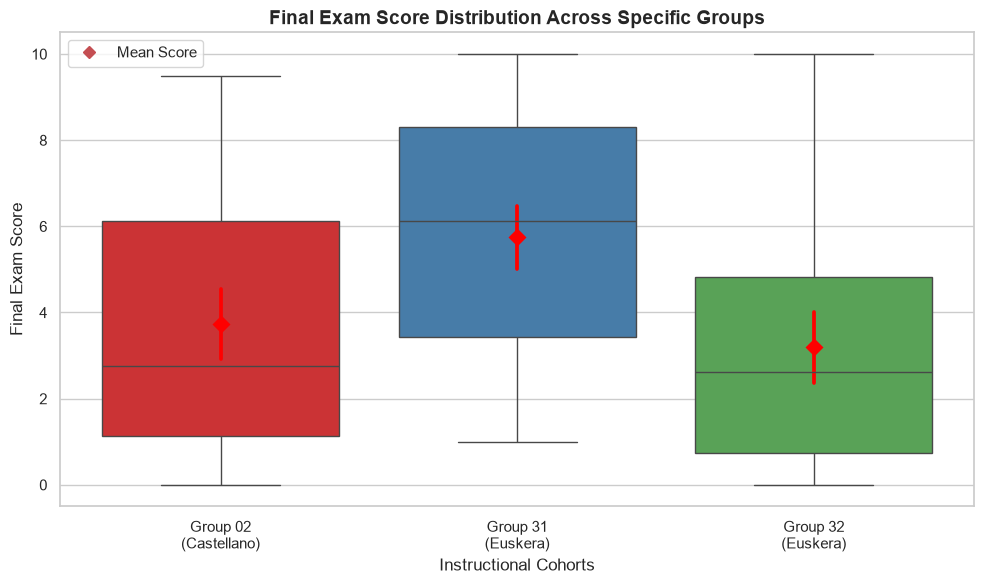

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the data
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# Calculating means and medians of the Final Exam Score by groups
print("Final Score Statistics of Groups:")
print(df.groupby('GRUPO')['Nota Examen'].agg(['mean', 'median', 'count']))

# Shortening names on the X-axis to prevent overlapping
group_names = {
    '02 (Castellano - Mañana)': 'Group 02\n(Castellano)',
    '31 (Euskera - Mañana)': 'Group 31\n(Euskera)',
    '32 (Euskera - Mañana)': 'Group 32\n(Euskera)'
}
df['Group_Short'] = df['GRUPO'].map(group_names)

# Starting to plot the graph
plt.figure(figsize=(10, 6))

# Plotting boxplots (showing distribution and median)
sns.boxplot(data=df, x='Group_Short', y='Nota Examen', palette='Set1', order=['Group 02\n(Castellano)', 'Group 31\n(Euskera)', 'Group 32\n(Euskera)'])

# Adding means as red diamonds on top of the boxes
sns.pointplot(data=df, x='Group_Short', y='Nota Examen', estimator='mean', color='red', markers='D', linestyles='', order=['Group 02\n(Castellano)', 'Group 31\n(Euskera)', 'Group 32\n(Euskera)'])

# Naming the graph
plt.title('Final Exam Score Distribution Across Specific Groups', fontsize=14, fontweight='bold')
plt.xlabel('Instructional Cohorts', fontsize=12)
plt.ylabel('Final Exam Score', fontsize=12)

# Adding a legend to explain the red diamond
plt.plot([], [], 'rD', label='Mean Score')
plt.legend()

plt.tight_layout()
plt.show()

9.CORRELATION MATRICES OF ALGORITHMIC THINKING AND ABSTRACTION SKILLS

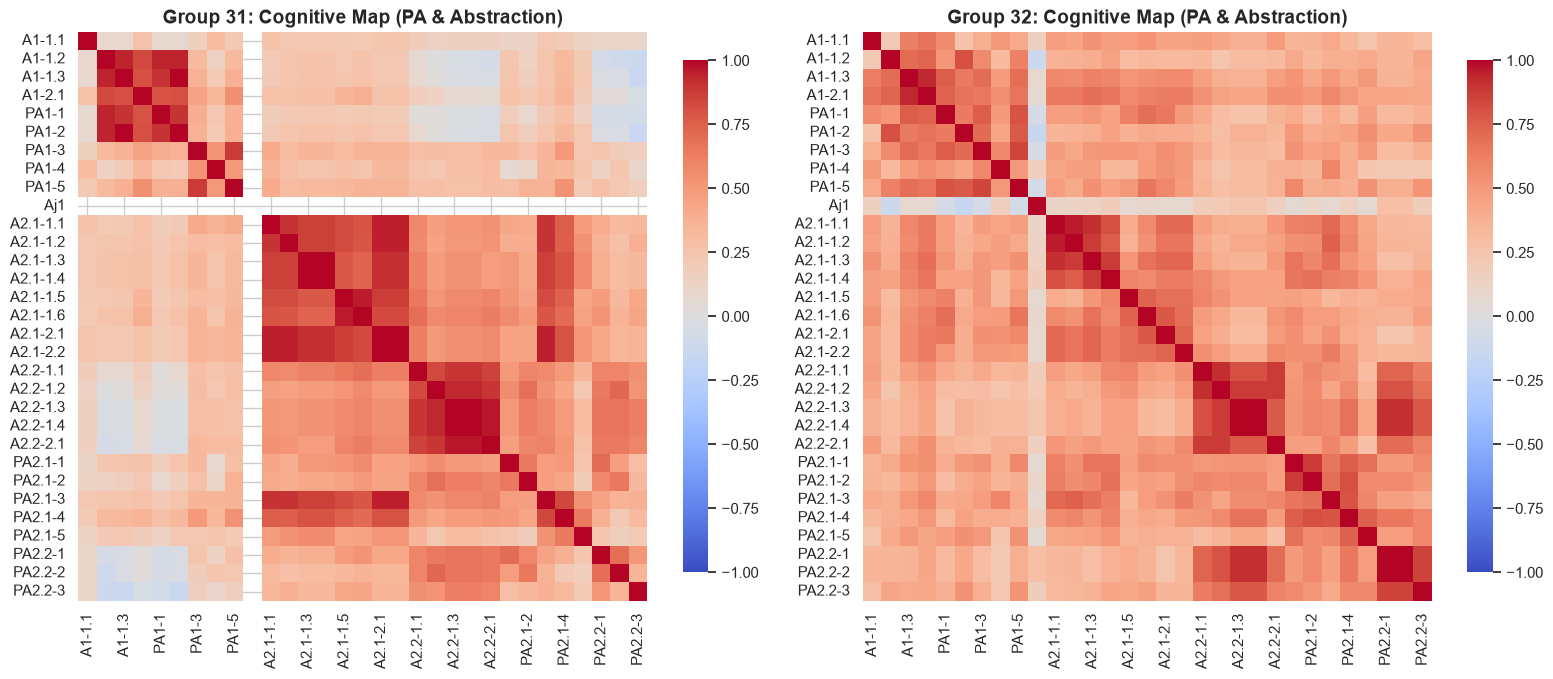

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the data
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# Cleaning the erroneous value 10
df['A2.1-1.6'] = pd.to_numeric(df['A2.1-1.6'], errors='coerce')
df.loc[df['A2.1-1.6'] == 10.0, 'A2.1-1.6'] = np.nan

# Selecting only PA (Algorithmic) and A (Abstraction) skills
target_columns = [col for col in df.columns if str(col).startswith(('PA', 'A')) and col != 'ASIGNATURA']

# Separating groups 31 and 32
df_31 = df[df['GRUPO'] == '31 (Euskera - Mañana)'][target_columns].apply(pd.to_numeric, errors='coerce')
df_32 = df[df['GRUPO'] == '32 (Euskera - Mañana)'][target_columns].apply(pd.to_numeric, errors='coerce')

# Calculating the correlations of the two groups separately
corr_31 = df_31.corr()
corr_32 = df_32.corr()

# Plotting two side-by-side Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Group 31 Map
sns.heatmap(corr_31, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
axes[0].set_title('Group 31: Cognitive Map (PA & Abstraction)', fontsize=14, fontweight='bold')

# Group 32 Map
sns.heatmap(corr_32, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
axes[1].set_title('Group 32: Cognitive Map (PA & Abstraction)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

10.PERFORMANCE BY ENGINEERING MAJOR (FINAL EXAM SCORE) - THE UNDERDOG EFFECT

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_24736/1530682909.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TITULACIÓN', y='Nota Examen', palette='viridis')


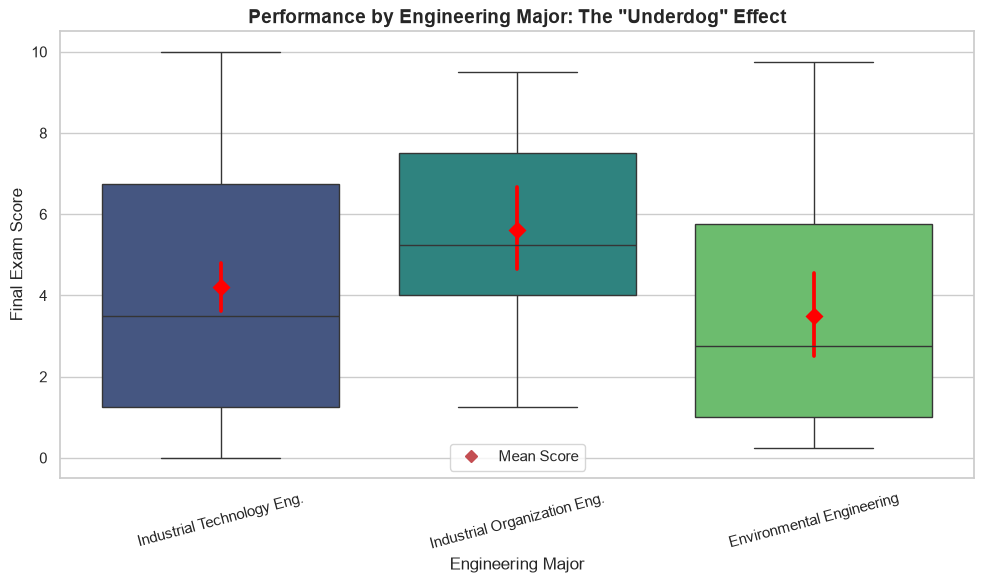

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the data
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# --- ENGLISH DATA TRANSLATION ---
df['TITULACIÓN'] = df['TITULACIÓN'].replace({
    'Grado en Ingeniería en Tecnología Industrial': 'Industrial Technology Eng.',
    'Grado en Ingeniería en Organización Industrial': 'Industrial Organization Eng.',
    'Grado en Ingeniería Ambiental': 'Environmental Engineering'
})

plt.figure(figsize=(10, 6))

# Plotting the boxplots
sns.boxplot(data=df, x='TITULACIÓN', y='Nota Examen', palette='viridis')

# Adding means as red diamonds on top of the boxes
sns.pointplot(data=df, x='TITULACIÓN', y='Nota Examen', estimator='mean', color='red', markers='D', linestyles='')

# Naming the graph
plt.title('Performance by Engineering Major: The "Underdog" Effect', fontsize=14, fontweight='bold')
plt.xlabel('Engineering Major', fontsize=12)
plt.ylabel('Final Exam Score', fontsize=12)

# Rotating the labels slightly if they are too long
plt.xticks(rotation=15) 

# Adding a legend to explain the red diamond
plt.plot([], [], 'rD', label='Mean Score')
plt.legend()

plt.tight_layout()
plt.show()

11.ALGORITHMIC THINKING BY ENGINEERING MAJOR

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_24736/3610990593.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TITULACIÓN', y='PA1-1', palette='viridis')


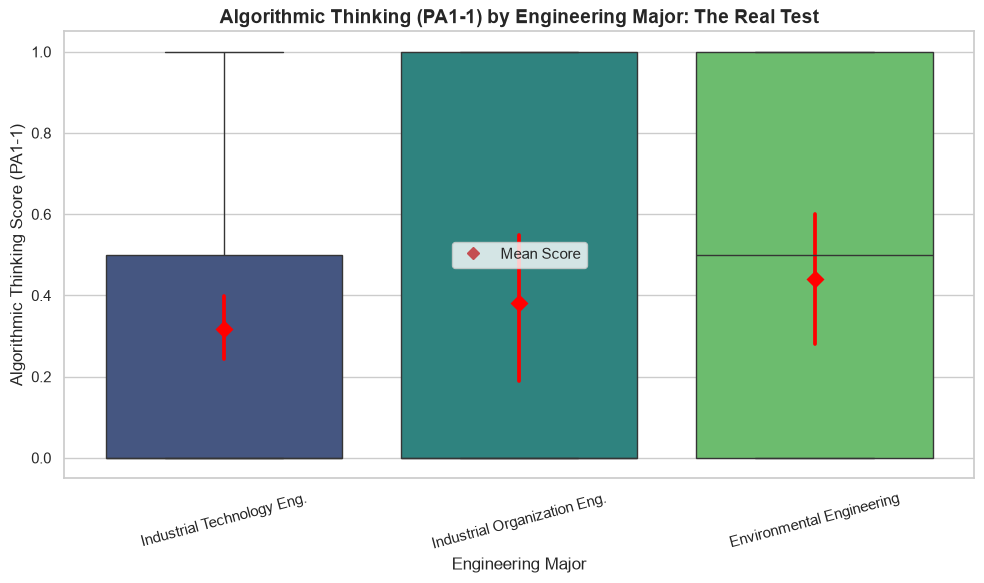

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the data
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# --- ENGLISH DATA TRANSLATION ---
df['TITULACIÓN'] = df['TITULACIÓN'].replace({
    'Grado en Ingeniería en Tecnología Industrial': 'Industrial Technology Eng.',
    'Grado en Ingeniería en Organización Industrial': 'Industrial Organization Eng.',
    'Grado en Ingeniería Ambiental': 'Environmental Engineering'
})

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='TITULACIÓN', y='PA1-1', palette='viridis')
sns.pointplot(data=df, x='TITULACIÓN', y='PA1-1', estimator='mean', color='red', markers='D', linestyles='')

plt.title('Algorithmic Thinking (PA1-1) by Engineering Major: The Real Test', fontsize=14, fontweight='bold')
plt.xlabel('Engineering Major', fontsize=12) 
plt.ylabel('Algorithmic Thinking Score (PA1-1)', fontsize=12)
plt.xticks(rotation=15) 

plt.plot([], [], 'rD', label='Mean Score')
plt.legend()
plt.tight_layout()
plt.show()

12.COGNITIVE MAPPING AND HIDDEN PROFILES

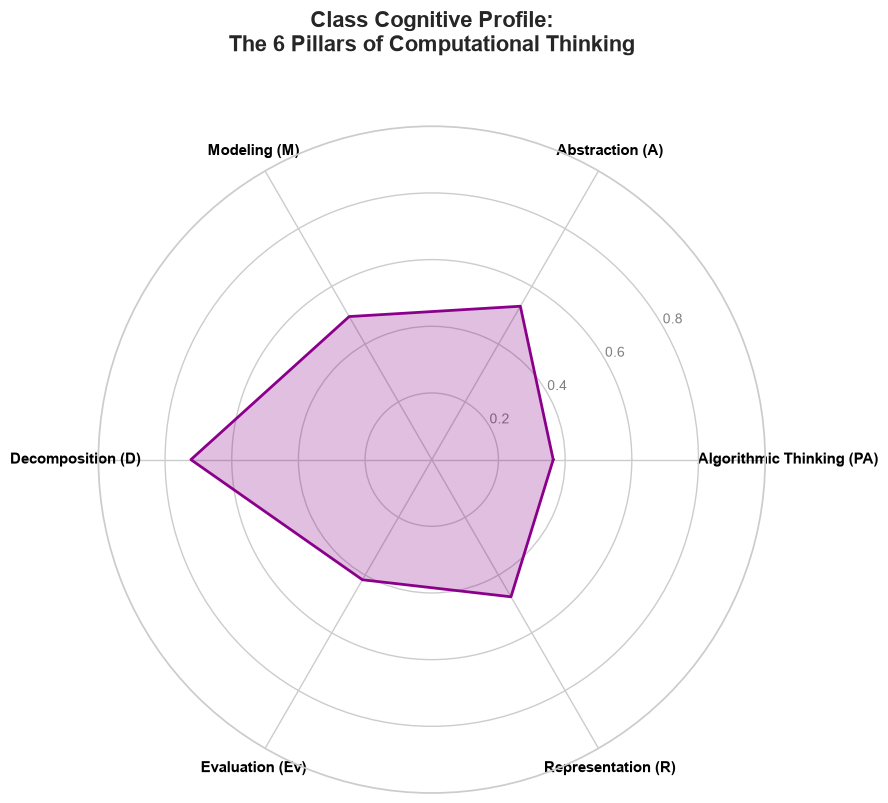

=== MAKRO CT BECERİLERİ GENEL ORTALAMASI ===
Decomposition (D): 0.723
Abstraction (A): 0.531
Modeling (M): 0.496
Representation (R): 0.475
Evaluation (Ev): 0.416
Algorithmic Thinking (PA): 0.364


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 1. Veri Yükleme ve Hata Temizliği
dosya_yolu = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(dosya_yolu, header=1)

df['A2.1-1.6'] = pd.to_numeric(df['A2.1-1.6'], errors='coerce')
df.loc[df['A2.1-1.6'] == 10.0, 'A2.1-1.6'] = np.nan

# Metadata'yı atalım (Becerilere karışmasınlar)
istemeyen_sutunlar = ['Aj1', 'J1', 'CONVOCATORIAS', 'CHICO = 0    CHICA = 1', 'ASIGNATURA']
for col in istemeyen_sutunlar:
    if col in df.columns:
        df = df.drop(columns=[col])

df_sayisal = df.select_dtypes(include=['float64', 'int64'])

# 2. Bütün Sütunları 6 Ana Kategoriye Gruplama
kategoriler = {
    'Algorithmic Thinking (PA)': [],
    'Abstraction (A)': [],
    'Modeling (M)': [],
    'Decomposition (D)': [],
    'Evaluation (Ev)': [],
    'Representation (R)': []
}

for col in df_sayisal.columns:
    col_str = str(col)
    if col_str.startswith('PA'):
        kategoriler['Algorithmic Thinking (PA)'].append(col)
    elif col_str.startswith('Ev'):
        kategoriler['Evaluation (Ev)'].append(col)
    elif col_str.startswith('R'):
        kategoriler['Representation (R)'].append(col)
    elif col_str.startswith('M'):
        kategoriler['Modeling (M)'].append(col)
    elif col_str.startswith('D'):
        kategoriler['Decomposition (D)'].append(col)
    elif col_str.startswith('A'): 
        kategoriler['Abstraction (A)'].append(col)

# Hatalı girişleri (1.0'dan büyük olanları) NaN yaparak temizleme
df_sayisal = df_sayisal.mask(df_sayisal > 1.0)

# 3. Her Kategori İçin Genel CT Ortalamasını Hesaplama
kategori_ortalamalari = {}
for kat, sutunlar in kategoriler.items():
    if len(sutunlar) > 0:
        # Önce ilgili sütunları al, ortalamalarını hesapla, sonra hepsinin genel ortalamasını al
        kategori_ortalamalari[kat] = df_sayisal[sutunlar].mean().mean()

# 4. GÖRSELLEŞTİRME: Radar (Örümcek Ağı) Grafiği Veri Hazırlığı
kategori_isimleri = list(kategori_ortalamalari.keys())
degerler = list(kategori_ortalamalari.values())

# Grafiğin dairesel olarak kapanması için ilk değeri sona ekliyoruz
degerler += degerler[:1]
aci_sayisi = len(kategori_isimleri)
acilar = [n / float(aci_sayisi) * 2 * pi for n in range(aci_sayisi)]
acilar += acilar[:1]

# Grafiği Çizdirme
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

plt.xticks(acilar[:-1], kategori_isimleri, color='black', size=11, fontweight='bold')
ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=10)
plt.ylim(0, 1)

# Alanı mor renk ile dolduruyoruz
ax.plot(acilar, degerler, linewidth=2, linestyle='solid', color='darkmagenta')
ax.fill(acilar, degerler, 'darkmagenta', alpha=0.25)

plt.title("Class Cognitive Profile:\nThe 6 Pillars of Computational Thinking", size=16, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()

# Terminale sayısal verileri de yazdıralım
print("=== MAKRO CT BECERİLERİ GENEL ORTALAMASI ===")
for k, v in sorted(kategori_ortalamalari.items(), key=lambda item: item[1], reverse=True):
    print(f"{k}: {v:.3f}")


13.COGNITIVE PROFILES AND COGNITIVE DNA

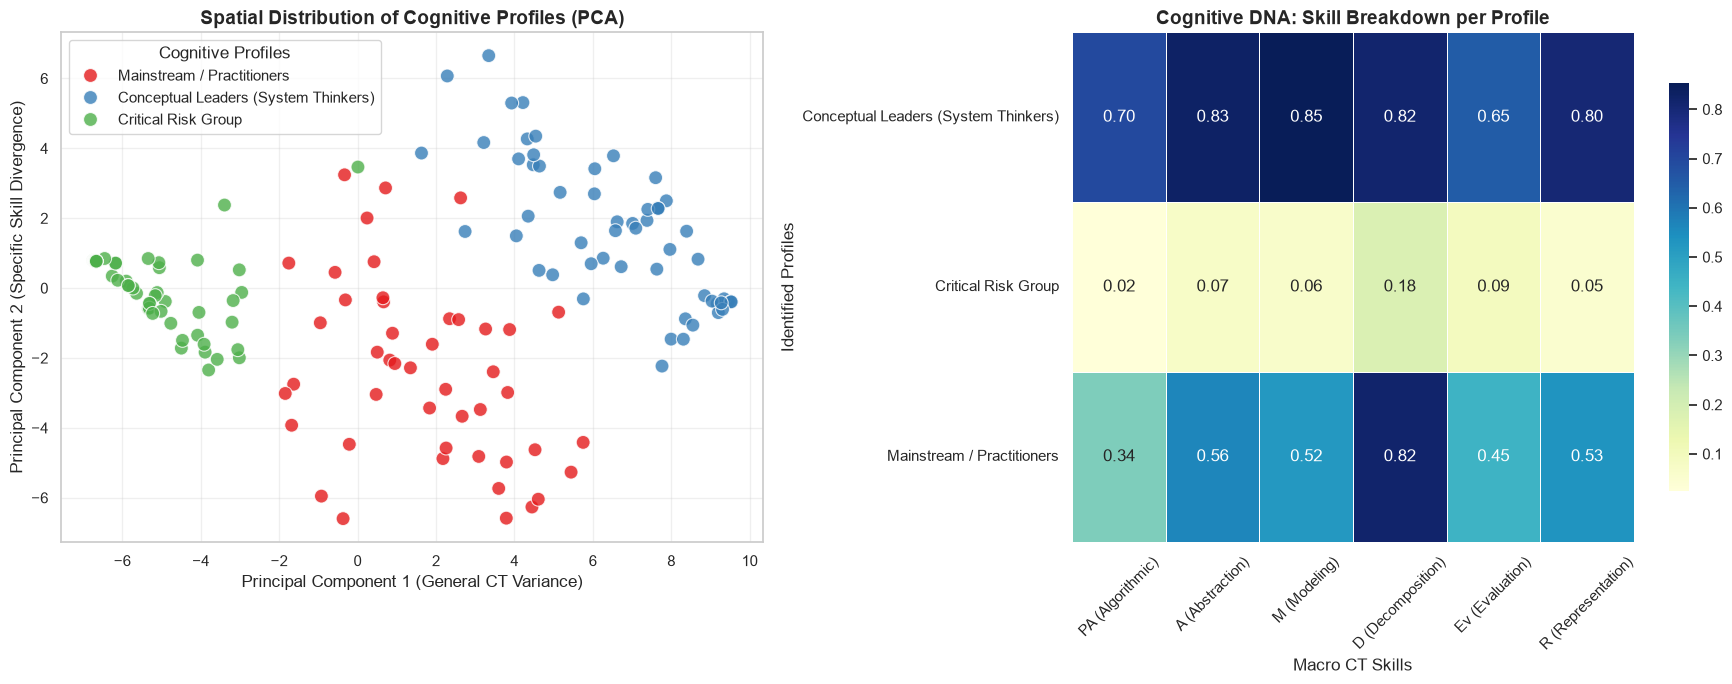

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Data Loading and Cleaning
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)
df['A2.1-1.6'] = pd.to_numeric(df['A2.1-1.6'], errors='coerce')
df.loc[df['A2.1-1.6'] == 10.0, 'A2.1-1.6'] = np.nan

skill_columns = [col for col in df.columns if str(col).startswith(('PA', 'A', 'M', 'D', 'Ev', 'R')) and col != 'ASIGNATURA']
df_analysis = df[skill_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

# 2. Machine Learning (K-Means & PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_analysis)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_analysis['Cluster_Name'] = 'Profile ' + (kmeans.fit_predict(X_scaled) + 1).astype(str)

# ---> NAMING TRANSLATED TO ENGLISH <---
profile_names = {
    'Profile 1': 'Mainstream / Practitioners',
    'Profile 2': 'Critical Risk Group',
    'Profile 3': 'Conceptual Leaders (System Thinkers)'
}
df_analysis['Cluster_Name'] = df_analysis['Cluster_Name'].map(profile_names)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_analysis['PCA1'] = X_pca[:, 0]
df_analysis['PCA2'] = X_pca[:, 1]

# 3. Cognitive DNA Preparation (Macro Skills)
categories = {
    'PA (Algorithmic)': [col for col in df_analysis.columns if col.startswith('PA')],
    'A (Abstraction)': [col for col in df_analysis.columns if col.startswith('A')],
    'M (Modeling)': [col for col in df_analysis.columns if col.startswith('M')],
    'D (Decomposition)': [col for col in df_analysis.columns if col.startswith('D') and not col.startswith('DNI')],
    'Ev (Evaluation)': [col for col in df_analysis.columns if col.startswith('Ev')],
    'R (Representation)': [col for col in df_analysis.columns if col.startswith('R')]
}

for name, columns in categories.items():
    if len(columns) > 0:
        df_analysis[name] = df_analysis[columns].mean(axis=1)

profile_summary = df_analysis.groupby('Cluster_Name')[list(categories.keys())].mean()

# 4. TWO GRAPHS IN ONE FIGURE (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left Graph: PCA Distribution ---
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Name', data=df_analysis, palette='Set1', s=100, alpha=0.8, ax=axes[0])
axes[0].set_title('Spatial Distribution of Cognitive Profiles (PCA)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Principal Component 1 (General CT Variance)')
axes[0].set_ylabel('Principal Component 2 (Specific Skill Divergence)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Cognitive Profiles') 

# --- Right Graph: Cognitive DNA Heatmap ---
sns.heatmap(profile_summary, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5, ax=axes[1], cbar_kws={"shrink": .8})
axes[1].set_title('Cognitive DNA: Skill Breakdown per Profile', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Identified Profiles')
axes[1].set_xlabel('Macro CT Skills')
axes[1].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

14.GENDER SUCCESS CORRELATION

/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_24736/906704797.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Nota Examen', palette=['#3498db', '#e74c3c'])
/var/folders/pb/xt65zwld3hj14_423ywnqrj40000gn/T/ipykernel_24736/906704797.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='PA1-1', palette=['#3498db', '#e74c3c'])


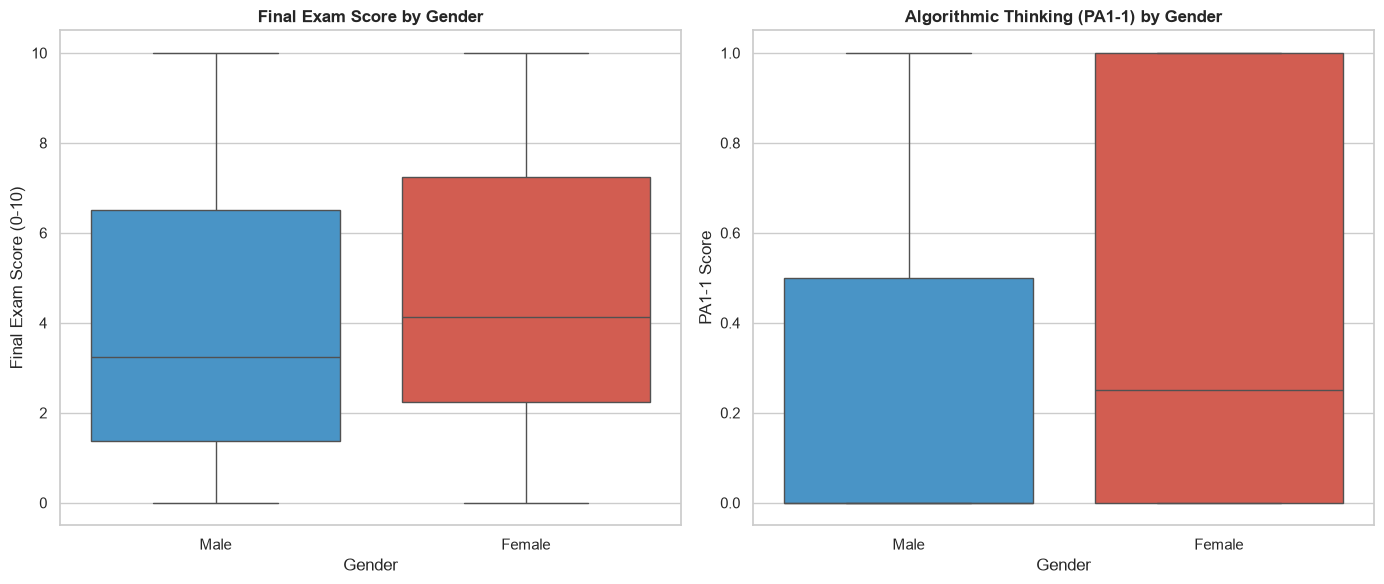

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA LOADING ---
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# Automatically finding the Gender column 
gender_col_candidates = [col for col in df.columns if 'CHICO' in str(col).upper()]
actual_gender_col = gender_col_candidates[0] if gender_col_candidates else None

if actual_gender_col:
    df['Gender'] = df[actual_gender_col].map({0.0: 'Male', 1.0: 'Female'})

    # --- GENDER VS. SUCCESS ANALYSIS ---
    plt.figure(figsize=(14, 6))

    # Graph 1: Final Score Comparison
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df, x='Gender', y='Nota Examen', palette=['#3498db', '#e74c3c'])
    plt.title("Final Exam Score by Gender", fontweight='bold')
    plt.ylabel("Final Exam Score (0-10)")
    plt.xlabel("Gender")

    # Graph 2: Comparison of the Toughest Skill (PA1-1)
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x='Gender', y='PA1-1', palette=['#3498db', '#e74c3c'])
    plt.title("Algorithmic Thinking (PA1-1) by Gender", fontweight='bold')
    plt.ylabel("PA1-1 Score")
    plt.xlabel("Gender")

    plt.tight_layout()
    plt.show()
else:
    print("Gender column not found, check Excel headers!")

15.GENDER GAP ANALYSIS - COGNITIVE DIFFERENCES

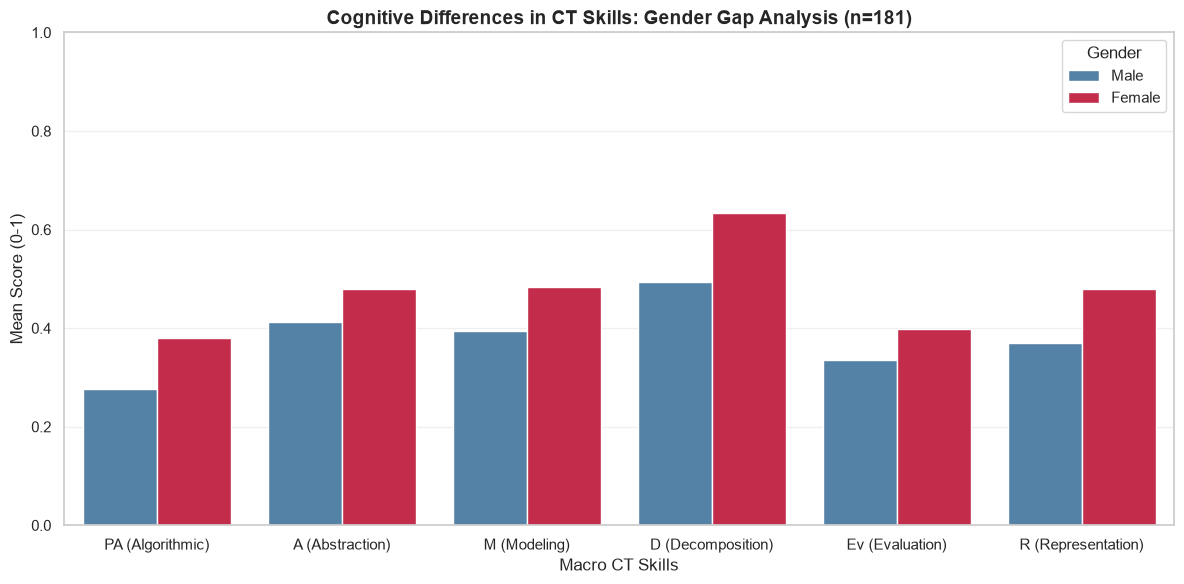

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading
file_path = "Data_CT_Kal_20_arik-4-5.xlsx"
df = pd.read_excel(file_path, header=1)

# 2. Preparing the Gender Column
gender_col = 'CHICO = 0    CHICA = 1'
df = df.dropna(subset=[gender_col]) 

# ---> CHANGED TO ONLY ENGLISH <---
df['Gender'] = df[gender_col].map({0: 'Male', 1: 'Female'})

# 3. Grouping Macro Skills 
categories = {
    'PA (Algorithmic)': [col for col in df.columns if str(col).startswith('PA')],
    'A (Abstraction)': [col for col in df.columns if str(col).startswith('A') and col != 'ASIGNATURA'],
    'M (Modeling)': [col for col in df.columns if str(col).startswith('M')],
    'D (Decomposition)': [col for col in df.columns if str(col).startswith('D') and not str(col).startswith('DNI')],
    'Ev (Evaluation)': [col for col in df.columns if str(col).startswith('Ev')],
    'R (Representation)': [col for col in df.columns if str(col).startswith('R')]
}

# 4. Calculating Mean Scores 
for name, columns in categories.items():
    if len(columns) > 0:
        df[name] = df[columns].apply(pd.to_numeric, errors='coerce').fillna(0).mean(axis=1)

# 5. Transforming Data for Visualization (Melt)
plot_data = df[['Gender'] + list(categories.keys())].melt(id_vars='Gender', var_name='Skill', value_name='Score')

# 6. Plotting the Graph
plt.figure(figsize=(12, 6))

# ---> PALETTE NAMES MATCHED WITH THE NEW ENGLISH FORMAT <---
sns.barplot(data=plot_data, x='Skill', y='Score', hue='Gender', palette={'Male': 'steelblue', 'Female': 'crimson'}, errorbar=None)

plt.title('Cognitive Differences in CT Skills: Gender Gap Analysis (n=181)', fontsize=14, fontweight='bold')
plt.xlabel('Macro CT Skills', fontsize=12)
plt.ylabel('Mean Score (0-1)', fontsize=12)
plt.ylim(0, 1) 
plt.legend(title='Gender', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()